In [9]:
import json
from pathlib import Path

%matplotlib inline
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

root = Path(r"C:\Users\cris\CS\MealHistory2020-01-01_2026-09-21")
data_path = root / "MealHistory_UTF8.csv"
df = pd.read_csv(data_path, encoding="utf-8-sig")
df.head()

,STT,Mã chấm công,Họ tên,Phòng ban,Khẩu phần ăn,Món ăn,Khẩu phần ăn bồi dưỡng,Ca ăn,Thành tiền,Tổng tích lũy,Thời gian ăn,Trạng thái,Lý do
0,1.0,3905.0,?oàn Ng?c Th?ch,07.Team06,NaN,NaN,NaN,NaN,NaN,0.0,7/1/2025 17:53,Không hợp lệ,Chưa đến thời gian ca ăn
1,2.0,3712.0,Tr?n Th? H?ng,07.Team06,NaN,NaN,NaN,NaN,NaN,0.0,7/1/2025 17:53,Không hợp lệ,Chưa đến thời gian ca ăn
2,3.0,3509.0,Nguy?n Khánh C??ng,03.Team14,NaN,NaN,NaN,NaN,NaN,0.0,7/1/2025 17:53,Không hợp lệ,Chưa đến thời gian ca ăn
3,4.0,3471.0,Nguyê?n Kim C?,03.Team14,NaN,NaN,NaN,NaN,NaN,0.0,7/1/2025 17:53,Không hợp lệ,Chưa đến thời gian ca ăn
4,5.0,3747.0,Lê Thanh Ph??c,07.Team06,NaN,NaN,NaN,NaN,NaN,0.0,7/1/2025 17:53,Không hợp lệ,Chưa đến thời gian ca ăn


In [10]:
total_rows = len(df)
valid_rows = (df["Trạng thái"] == "Hợp lệ").sum()
invalid_rows = (df["Trạng thái"] == "Không hợp lệ").sum()
total_amount = pd.to_numeric(df["Thành tiền"], errors="coerce").fillna(0).sum()

summary = {
    "Tổng số dùng": int(total_rows),
    "Dùng hợp lệ": int(valid_rows),
    "Dùng không hợp lệ": int(invalid_rows),
    "Tổng tiền": float(total_amount),
}

summary


{'Tổng số dùng': 409885,
 'Dùng hợp lệ': 364101,
 'Dùng không hợp lệ': 45783,
 'Tổng tiền': 17024456000.0}

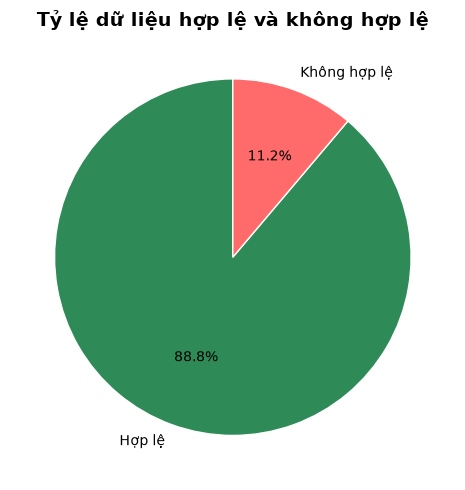

In [11]:
labels = ["Hợp lệ", "Không hợp lệ"]
sizes = [valid_rows, invalid_rows]
colors = ["#2E8B57", "#FF6B6B"]

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors, wedgeprops={"edgecolor": "white"}
)
ax.set_title("Tỷ lệ dữ liệu hợp lệ và không hợp lệ", fontsize=14, fontweight="bold")
plt.tight_layout()
display(fig)
plt.close(fig)

In [12]:
model_df = pd.DataFrame({
    "Mô hình": [
        "Xu hướng tuyến tính",
        "San bằng mũ",
        "Trung bình 7 ngày",
        "Trung vị cùng thứ",
        "Trung bình có trọng số",
        "Trung bình cùng thứ"
    ],
    "MAPE": [27.22, 28.45, 30.53, 35.23, 35.65, 37.43],
    "Accuracy": [72.78, 71.55, 69.47, 64.77, 64.35, 62.57],
    "Số ngày kiểm tra": [357, 357, 357, 357, 357, 357]
})

model_df


,Mô hình,MAPE,Accuracy,Số ngày kiểm tra
0,Xu hướng tuyến tính,27.22,72.78,357
1,San bằng mũ,28.45,71.55,357
2,Trung bình 7 ngày,30.53,69.47,357
3,Trung vị cùng thứ,35.23,64.77,357
4,Trung bình có trọng số,35.65,64.35,357
5,Trung bình cùng thứ,37.43,62.57,357


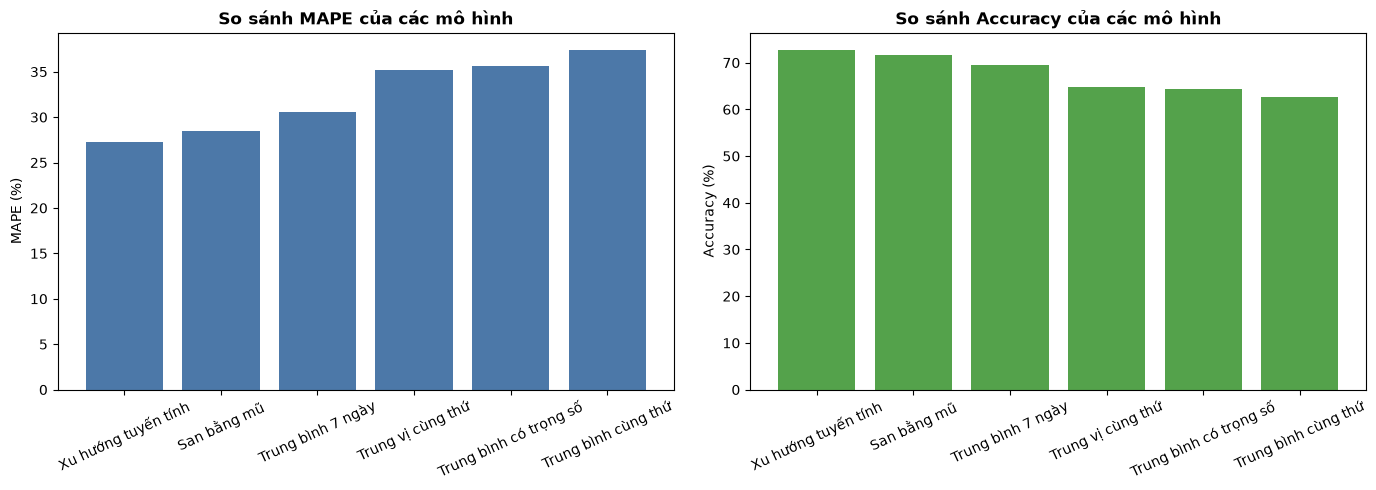

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(model_df["Mô hình"], model_df["MAPE"], color="#4C78A8")
axes[0].set_title("So sánh MAPE của các mô hình", fontsize=12, fontweight="bold")
axes[0].set_ylabel("MAPE (%)")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(model_df["Mô hình"], model_df["Accuracy"], color="#54A24B")
axes[1].set_title("So sánh Accuracy của các mô hình", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Accuracy (%)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
display(fig)
plt.close(fig)

In [14]:
chosen = {
    "MAE": 174.49,
    "RMSE": 252.34,
    "MAPE": 27.22,
    "Accuracy": 72.78,
    "Coverage": 74.51,
    "Interval Width": 578.91,
}

metric_df = pd.DataFrame({
    "Chỉ số": ["MAE", "RMSE", "MAPE", "Accuracy", "Coverage", "Interval Width"],
    "Giá trị": [174.49, 252.34, 27.22, 72.78, 74.51, 578.91],
    "Đơn vị": ["số lần", "số lần", "%", "%", "%", "số lần"]
})

metric_df


,Chỉ số,Giá trị,Đơn vị
0,MAE,174.49,số lần
1,RMSE,252.34,số lần
2,MAPE,27.22,%
3,Accuracy,72.78,%
4,Coverage,74.51,%
5,Interval Width,578.91,số lần


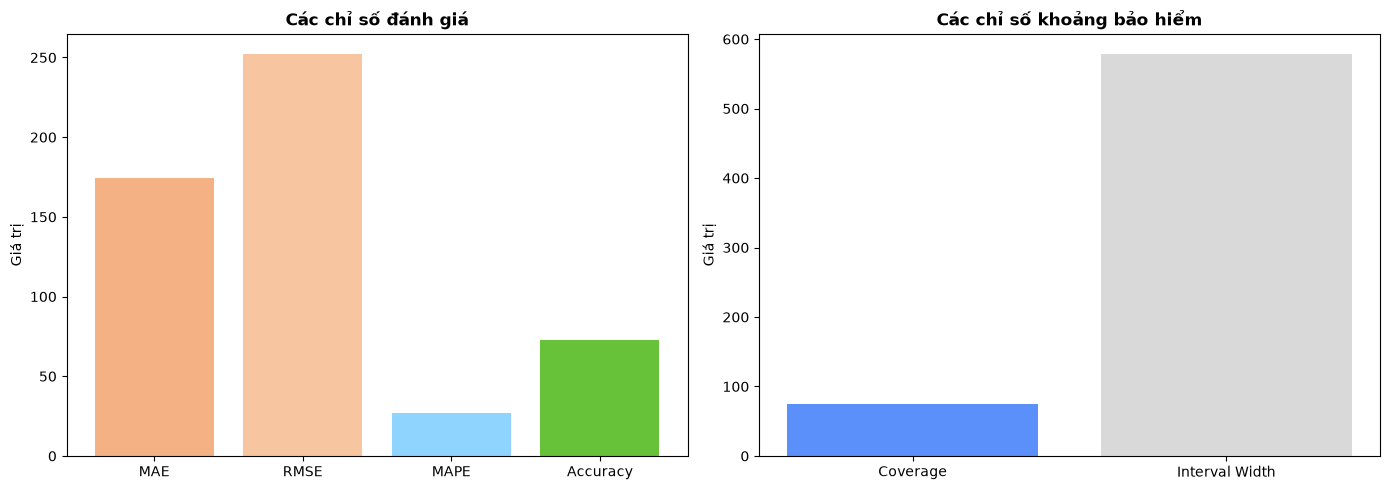

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

point_metrics = ["MAE", "RMSE", "MAPE", "Accuracy"]
point_values = [174.49, 252.34, 27.22, 72.78]

axes[0].bar(point_metrics, point_values, color=["#F4B183", "#F7C59F", "#8FD3FF", "#67C23A"])
axes[0].set_title("Các chỉ số đánh giá", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Giá trị")
axes[0].tick_params(axis="x", rotation=0)

interval_labels = ["Coverage", "Interval Width"]
interval_values = [74.51, 578.91]
axes[1].bar(interval_labels, interval_values, color=["#5B8FF9", "#D9D9D9"])
axes[1].set_title("Các chỉ số khoảng bảo hiểm", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Giá trị")

plt.tight_layout()
display(fig)
plt.close(fig)